<img src="../Decorative-Elements/Section-04/ADL-S04-Image-04-d.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/02-IAS15-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/04-JANUS-Integrator.ipynb" target="_blank">Next</a>
</p>

In [1]:
# leapfrog  : Simple symplectic integrator, conserves energy well, suitable for general N-body problems.

# Leapfrog Integrator - Important Use Case
# - Best for simulations requiring moderate accuracy with simple implementation.
# - Symplectic: conserves energy well for systems without extreme close encounters.
# - Efficient for N-body problems with uniform time steps, like asteroid belts or star clusters.
# - Easy to implement for both 1D and 3D systems, making it popular in educational and research contexts.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Constants
G = 4 * np.pi**2  # Gravitational constant in AU^3 / yr^2 / Msun

# Simulation Parameters
dt = 0.01        # time step in years
t_max = 5        # total simulation time in years
steps = int(t_max/dt)  # number of steps

# Initialize Planet (Earth-like)
r = np.array([1.0, 0.0])       # initial position [AU]
v = np.array([0.0, 2*np.pi])   # initial velocity [AU/yr] for circular orbit
m = 3e-6                        # mass relative to Sun

# Sun at origin
r_sun = np.array([0.0, 0.0])
m_sun = 1.0

In [6]:
# Arrays to store data
positions = np.zeros((steps, 2))       # store planet trajectory
kinetic_energy = np.zeros(steps)       # store kinetic energy
potential_energy = np.zeros(steps)     # store potential energy
total_energy = np.zeros(steps)         # store total energy

In [7]:
# Leapfrog Integration Setup
# Kick-drift-kick scheme:
# Step 0: compute acceleration and update velocity by half-step
a = -G * m_sun * r / np.linalg.norm(r)**3
v_half = v + 0.5 * dt * a  # half-step "kick"

In [8]:
# Main Integration Loop
for i in range(steps):
    # Drift: full-step position update using half-step velocity
    r += dt * v_half
    
    # Compute acceleration at new position (gravity from Sun)
    a = -G * m_sun * r / np.linalg.norm(r)**3
    
    # Kick: full-step velocity update
    v_half += dt * a
    
    # Store current position
    positions[i] = r
    
    # Approximate full-step velocity for energy calculation
    v_full = v_half - 0.5 * dt * a
    
    # Compute energies
    kinetic_energy[i] = 0.5 * m * np.linalg.norm(v_full)**2
    potential_energy[i] = -G * m_sun * m / np.linalg.norm(r)
    total_energy[i] = kinetic_energy[i] + potential_energy[i]

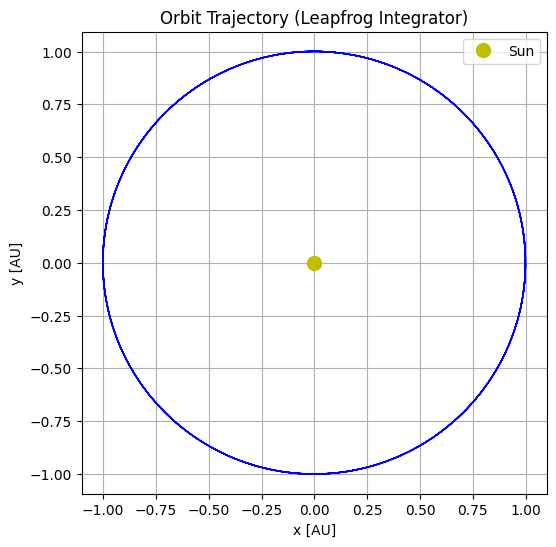

In [10]:
# Plot Orbital Trajectory
plt.figure(figsize=(6,6))
plt.plot(positions[:,0], positions[:,1], color='blue', lw=1)
plt.plot(0, 0, 'yo', markersize=10, label='Sun')  # Sun at origin
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Orbit Trajectory (Leapfrog Integrator)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

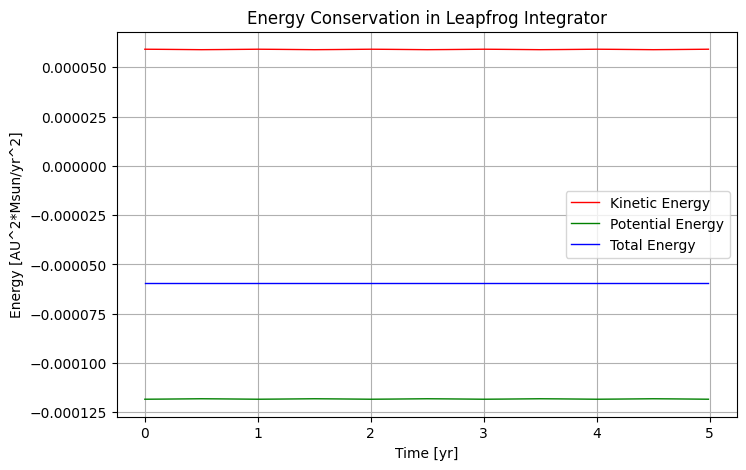

In [11]:
# Plot Energy Conservation
plt.figure(figsize=(8,5))
plt.plot(np.arange(steps)*dt, kinetic_energy, label='Kinetic Energy', color='red', lw=1)
plt.plot(np.arange(steps)*dt, potential_energy, label='Potential Energy', color='green', lw=1)
plt.plot(np.arange(steps)*dt, total_energy, label='Total Energy', color='blue', lw=1)
plt.xlabel('Time [yr]')
plt.ylabel('Energy [AU^2*Msun/yr^2]')
plt.title('Energy Conservation in Leapfrog Integrator')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# 1. Initialization:
#    - We set up a Sun at the origin and an Earth-like planet with initial
#      circular orbit conditions.
#    - Position (r) and velocity (v) are vectors in 2D.

# 2. Leapfrog Mechanics:
#    - 'Kick-drift-kick' method:
#        a) Kick: update velocity by half time-step using current acceleration.
#        b) Drift: update position by full time-step using half-step velocity.
#        c) Kick: update velocity by another half-step using new acceleration.
#    - This symplectic approach keeps the total energy nearly constant over long times.

# 3. Energy Calculation:
#    - Approximate full-step velocity is used to compute kinetic energy.
#    - Potential energy comes from Sun-planet gravitational attraction.
#    - Total energy remains nearly constant, confirming energy conservation.

# 4. Output:
#    - First plot: orbital trajectory of the planet.
#    - Second plot: kinetic, potential, and total energy over time.
#      - Observe that total energy oscillates slightly but remains bounded,
#        demonstrating long-term stability.

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/02-IAS15-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/04-JANUS-Integrator.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-04-03.gif">